# Sprint 5 - Análisis Exploratorio de Datos (Sesiones)

En el presente caso se busca aplicar los conocimientos adquiridos para el desarrollo de un primer tipo de análisis específico que todo analista o científico de datos debe realizar: **Análisis Exploratorio de Datos** (EDA por sus siglas en inglés). Este análisis tiene como propósito estudiar el comportamiento de indicadores o métricas específicas derivadas a partir de los datos disponibles, para lo cual emplea fundamentalmente 3 herramientas:

* Estadística descriptiva: El área de la estadística enfocada en el resumen y presentación de variables a partir de valores.
* Estadística inferencial: El área de la estadística enfocada en la verificación de hipótesis a partir de información existente.
* Visualización (lo cual ya lo has venido practicando en los capítulos anteriores).

Como puedes evidenciar, saber estadística te ayudará mucho en tu camino como analista o científico de datos. Te recomiendo por tanto que escuches este playlist sobre Fundamentos de Estadística creado por el canal StatQuest de Josh Starmer: https://youtube.com/playlist?list=PLblh5JKOoLUK0FLuzwntyYI10UQFUhsY9&si=fTrXd4SYsSvR_iVe.

## Entendimiento del contexto

El Banco Mundial es un organismo multinacional cuyo propósito es el brindar asistencia económica y financiera a sus estados asociados. Entre los servicios que ofrece se encuentra la de generar y publicar diversos indicadores macroeconómicos, sociales, demográficos y ambientales que permiten estudiar y contrastar la situación multidimensional entre países a través de los años. Si es de tu interés, puedes acceder a todo su catálogo de información en https://data.worldbank.org/.

Un dato importante para que tengas en cuenta es que a nivel mundial se reconocen poco más de 200 estados, de los cuales algunos proveen de información al Banco Mundial (estados miembro) y otros no lo hacen. La entidad si le es posible estima mediante modelos econométricos algunos de estos indicadores faltantes. 

En este sentido, el Banco Mundial te ha contratado para que realices un análisis respecto al comportamiento de la variación del Producto Interno Bruto (PIB) entre los años 2000 y 2023. En concreto, esta entidad quiere que le asistas contestando las siguientes preguntas:

* ¿Cuál ha sido el comportamiento de este indicador en todo el período estudiado?
* ¿Qué variables inciden principalmente en los cambios a nivel de este indicador?
* ¿Qué tan probable es que un país tenga una recesión (reducción del PIB) en un año cualquiera?
* ¿Existen diferencias significativas en el crecimiento de países de "bajo desarrollo" frente a países de "alto desarrollo"?

## Entendimiento de los datos

La entidad te ha compartido la siguiente información en la que quiere que bases tu análisis:

* **cat_codpais3**: [264 filas, 2 columnas] Catálogo que contiene el nombre del país y sus siglas *Alpha-3* de acuerdo a la normativa ISO.
* **wb_ahorro**: [265, 25] Series anuales 2000 - 2023 por país respecto al porcentaje promedio de ahorro que mantienen los habitantes como porcentaje de su ingreso. 
* **wb_crecimpib**: [265, 25] Series anuales 2000 - 2023 por país respecto a la tasa de variación del PIB. 
* **wb_crecimpob**: [265, 25] Series anuales 2000 - 2023 por país respecto a la tasa de variación de la población.
* **wb_poburbana**: [265, 25] Series anuales 2000 - 2023 por país respecto al porcentaje de la población que reside en áreas urbanas.

Vale señalar que cada uno de estos dataframes se encuentra en formato *csv*.

Antes que nada vale que importes las librerías que vas a utilizar, incluyendo una nueva llamada **Scipy** enfocada en funciones y métodos para análisis estadístico de datos.

In [1]:
# Cargar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

Vamos a importar además una librería llamada **Warnings**. Investiga para qué sirve esta librería y qué hace el siguiente código.

```py
import warnings
warnings.filterwarnings("ignore")
```

In [2]:
import warnings
warnings.filterwarnings("ignore")

Carga ahora los datos de todos los dataframes disponibles.

In [ ]:
# Cargar catalogo de codificacion de paises
cat_pais = pd.read_csv("cat_codpais3.csv")

# Cargar datos de ahorro por pais
df_ahorro = pd.read_csv("wb_ahorro.csv")

# Cargar datos de variacion del PIB
df_pib = pd.read_csv("wb_crecimpib.csv")

# Cargar datos de variacion de poblacion
df_poblacion = pd.read_csv("wb_crecimpob.csv")

# Cargar datos de porcentaje de poblacion urbana
df_urbana = pd.read_csv("wb_poburbana.csv")

Crea una función que te permita mirar: 

* La estructura general del dataset.
* Una muestra aleatoria de 5 filas en la que se presenten solamente las primeras 5 columnas del dataset.
* Un conteo de los duplicados existentes.

In [4]:
def fun_diagnostico (df):
    print("ESTRUCTURA GENERAL DE LA TABLA:")
    print(df.info())
    print("\n")
    print("MUESTRA DE LOS DATOS: ")
    print(df.sample(5).iloc[:,:5])
    print("\n")
    print(f"FILAS DUPLICADAS: {df.duplicated().sum()}")

Aplica la función creada en cada uno de los datasets del Banco Mundial.

In [5]:
fun_diagnostico(cat_pais)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_code  214 non-null    object
 1   country_name  214 non-null    object
dtypes: object(2)
memory usage: 3.5+ KB
None


MUESTRA DE LOS DATOS: 
    country_code                      country_name
39           COD  Congo, Republica Democratica del
171          SOM                           Somalia
104          KWT                            Kuwait
135          MYS                           Malasia
211          ZAF                         Sudafrica


FILAS DUPLICADAS: 0


In [6]:
fun_diagnostico(df_ahorro)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    object 
 1   2000          161 non-null    float64
 2   2001          160 non-null    float64
 3   2002          167 non-null    float64
 4   2003          169 non-null    float64
 5   2004          169 non-null    float64
 6   2005          187 non-null    float64
 7   2006          190 non-null    float64
 8   2007          195 non-null    float64
 9   2008          196 non-null    float64
 10  2009          198 non-null    float64
 11  2010          200 non-null    float64
 12  2011          201 non-null    float64
 13  2012          204 non-null    float64
 14  2013          204 non-null    float64
 15  2014          206 non-null    float64
 16  2015          207 non-null    float64
 17  2016          205 non-null    float64
 18

In [7]:
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    object 
 1   2000          246 non-null    float64
 2   2001          247 non-null    float64
 3   2002          247 non-null    float64
 4   2003          251 non-null    float64
 5   2004          251 non-null    float64
 6   2005          251 non-null    float64
 7   2006          251 non-null    float64
 8   2007          252 non-null    float64
 9   2008          252 non-null    float64
 10  2009          255 non-null    float64
 11  2010          255 non-null    float64
 12  2011          255 non-null    float64
 13  2012          255 non-null    float64
 14  2013          255 non-null    float64
 15  2014          256 non-null    float64
 16  2015          256 non-null    float64
 17  2016          255 non-null    float64
 18

In [8]:
fun_diagnostico(df_poblacion)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    object 
 1   2000          264 non-null    float64
 2   2001          264 non-null    float64
 3   2002          264 non-null    float64
 4   2003          264 non-null    float64
 5   2004          264 non-null    float64
 6   2005          264 non-null    float64
 7   2006          264 non-null    float64
 8   2007          264 non-null    float64
 9   2008          264 non-null    float64
 10  2009          264 non-null    float64
 11  2010          264 non-null    float64
 12  2011          264 non-null    float64
 13  2012          264 non-null    float64
 14  2013          264 non-null    float64
 15  2014          264 non-null    float64
 16  2015          264 non-null    float64
 17  2016          264 non-null    float64
 18

In [9]:
fun_diagnostico(df_urbana)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    object 
 1   2000          262 non-null    float64
 2   2001          262 non-null    float64
 3   2002          262 non-null    float64
 4   2003          262 non-null    float64
 5   2004          262 non-null    float64
 6   2005          262 non-null    float64
 7   2006          262 non-null    float64
 8   2007          262 non-null    float64
 9   2008          262 non-null    float64
 10  2009          262 non-null    float64
 11  2010          262 non-null    float64
 12  2011          262 non-null    float64
 13  2012          262 non-null    float64
 14  2013          262 non-null    float64
 15  2014          262 non-null    float64
 16  2015          262 non-null    float64
 17  2016          262 non-null    float64
 18

Hagamos ahora un experimento, filtra los datos de variación del PIB de Estados Unidos (USA) de los años 2013 a 2019. Guarda estos datos en una variable.

In [10]:
pib_usa = df_pib.loc[df_pib["Country Code"] == "USA","2013":"2019"]
print(pib_usa)

        2013     2014     2015      2016      2017      2018      2019
251  2.11783  2.52382  2.94555  1.819451  2.457622  2.966505  2.467038


Intenta ahora graficar estos datos con el método `plot` como usualmente lo has venido haciendo.

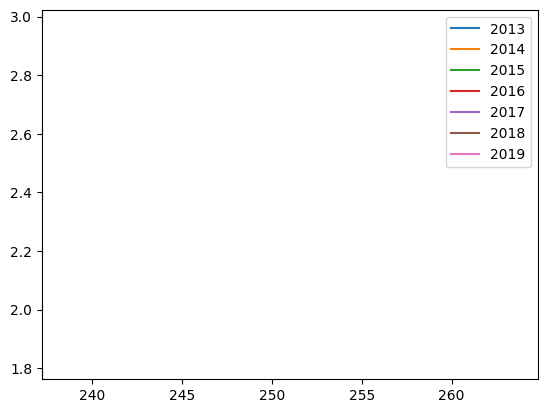

In [11]:
pib_usa.plot()
plt.show()

En cuanto a estos resultados notemos dos puntos importantes: 

* Por una parte, el filtrado no es tan natural como usualmente lo hacemos. De hecho resultaría imposible en este punto responder esta pregunta usando el método `query`. 
* Además no es posible graficar de forma directa y sencilla con el método `plot`. 

Esto se explica porque el dataset **df_pib** (y todos los demás con excepción de **cat_pais**) es **ANCHO**. Un dataset ancho es aquel en que cada fila representa a una única entidad (en este caso un país) que no se repite en otras filas. Su utilidad radica en que esta presentación de datos es fácil de interpretar por usuarios "no analíticos", justamente porque se puede acceder a la totalidad información de cada entidad de forma rápida y directa.

Sin embargo, para usuarios "analíticos" como nosotros esta presentación no es adecuada, pues nosotros queremos tablas **LARGAS**. En una tabla larga cada fila representa una observación (o lo que es lo mismo un dato) con sus diferentes variables y particularidades, y facilita en consecuencia la manipulación y visualización de información.

Visto todo esto, define tu plan de acción para preparar estos datos.

**PLAN DE ACCIÓN PARA PREPARACIÓN DE DATOS**

* La tabla **cat_pais** no presenta novedades por lo que se debe mantener en su estado actual.
* Para las demás tablas:
    * Es necesario transformar su presentación para que sean tablas *largas* que permitan su uso analítico.
    * Los nombres de las columnas deben ajustarse a formato *snake_case*.
    * Hemos evidenciado que existen valores perdidos en los diferentes datasets, sin embargo dado el contexto puede que estos respondan en a diferentes situación dependiendo del país al cual se corresponden (i.e países sin ningún valor, países con un pequeño número de casos ausentes, etc.). Se debe por tanto tomar una decisión sobre como tratarlos una vez que sea posible filtrar esta información fácilmente.
* Una vez realizados estos pasos, conviene unir todos los datasets en una única tabla consolidada.

## Preparación de datos

Vamos a empezar con **df_pib**. Transforma la presentación ancha de esta tabla a una de tipo *larga* aplicando el método `melt` o la función `wide_to_long`.

In [12]:
# Forma 1: Usando melt
df_pib = df_pib.melt(
    id_vars='Country Code', 
    var_name="year", 
    value_name="value"
)
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6360 entries, 0 to 6359
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  6360 non-null   object 
 1   year          6360 non-null   object 
 2   value         6051 non-null   float64
dtypes: float64(1), object(2)
memory usage: 149.2+ KB
None


MUESTRA DE LOS DATOS: 
     Country Code  year     value
5507          SEN  2020  1.342074
273           ARE  2001  1.399085
527           ZAF  2001  2.700000
5683          JOR  2021  3.655642
1969          ISL  2007  8.454860


FILAS DUPLICADAS: 0


```py
# Forma 2: Usando wide_to_long
df_pib = pd.wide_to_long(
    df_pib,
    stubnames = "",
    i = "Country Code",
    j = "year" 
).reset_index()
df_pib = df_pib.rename(columns = {"":"value"})
fun_diagnostico(df_pib)
```

Ajusta los nombres de las columnas para que estos sigan el formato *snake_case*.

In [13]:
df_pib.columns = [x.lower().replace(" ","_") for x in df_pib.columns]

Ya podemos estudiar los valores perdidos con esta tabla *larga*. Identifica diferentes tipologías de países en función de cuántos valores ausentes tengan.

In [14]:
# Obtener casos perdidos por país
casos_perdidos = (
    df_pib[df_pib['value'].isna()]
    .groupby("country_code")
    .agg(casos = ("country_code","count"))
    .sort_values(by = "casos", ascending = False)
    .reset_index()
)

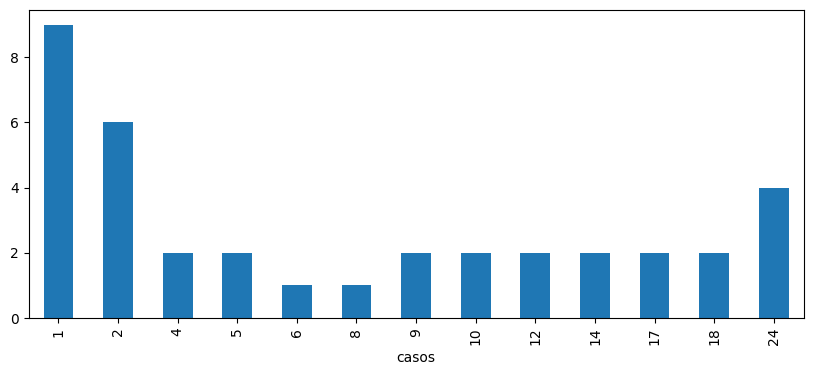

In [15]:
# Contar cuantos paises hay por la cantidad de valores perdidos
casos_por_pais = casos_perdidos["casos"].value_counts().sort_index()
casos_por_pais.plot(
    kind = "bar",
    figsize = [10,4]
)
plt.show()

Podríamos dividir a los países en 2 grupos en base a sus valores ausentes:

* Aquellos que tienen menos de un 20% (aprox. 5) de años sin valores.
* El resto que posee más del 20% de valores perdidos.

Para el último caso que correspondería a los países con pocos o ningún dato relevante, elimina todos estos registros pues su información está limitada pudiendo distorsionar los análisis.

In [16]:
paises_eliminar = list(casos_perdidos.query('casos > 5')["country_code"])
df_pib = df_pib[~df_pib["country_code"].isin(paises_eliminar)]

Para el primer caso, en donde existen muchos datos relevantes, aplica una imputación por el valor mediano de dicho país considerando que esto no alterará significativamente los resultados de los análisis.

In [17]:
# Obtener la mediana por pais
med_por_pais = (
    df_pib
    .groupby("country_code")
    .agg(med = ("value","median"))
    .reset_index()
)

In [18]:
# Incluir de forma temporal la mediana en el dataset
df_pib = df_pib.merge(
    med_por_pais,
    on = "country_code"
)

In [19]:
# Imputar la mediana en los casos perdidos correspondientes
for i in range(df_pib.shape[0]):
    if np.isnan(df_pib.loc[i,'value']):
        df_pib.loc[i,'value'] = df_pib.loc[i,"med"]

In [20]:
# Quitar columna de mediana 
df_pib = df_pib.drop(columns = "med")
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5928 entries, 0 to 5927
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  5928 non-null   object 
 1   year          5928 non-null   object 
 2   value         5928 non-null   float64
dtypes: float64(1), object(2)
memory usage: 139.1+ KB
None


MUESTRA DE LOS DATOS: 
     country_code  year     value
2153          PLW  2008 -5.493936
3403          SAS  2013  6.008602
5626          SAS  2022  6.312212
1814          GRL  2007  2.352438
4679          UKR  2018  3.488362


FILAS DUPLICADAS: 0


Concluye ejecutando los siguientes procedimientos de limpieza adicionales:

* Cambiar el tipo de variable de year a entero.
* Cambia el nombre de la columna value a algo más coherente con el contexto como *var_pib*.

In [21]:
# Cambiar el tipo de variable de year
df_pib['year'] = df_pib['year'].astype(int)

In [22]:
# Cambiar el nombre de la columna "value"
df_pib = df_pib.rename(columns={"value":"var_pib"})
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5928 entries, 0 to 5927
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  5928 non-null   object 
 1   year          5928 non-null   int32  
 2   var_pib       5928 non-null   float64
dtypes: float64(1), int32(1), object(1)
memory usage: 115.9+ KB
None


MUESTRA DE LOS DATOS: 
     country_code  year    var_pib
3544          GTM  2014   4.443978
1494          ATG  2006  12.708013
5810          LIC  2023   3.005655
3827          LAO  2015   7.270066
3312          IDX  2013   4.979412


FILAS DUPLICADAS: 0


Ahora bien, considera que este procedimiento debe repetirse exactamente igual en los datasets **df_ahorro**, **df_poblacion** y **df_urbana**. Haslo de forma **EFICIENTE**.

In [23]:
# Crear una funcion que permita automatizar el procedimiento de limpieza
def fun_procesamiento (df, nombre_col):
    
    # Transformar a tabla larga
    df = df.melt(id_vars='Country Code', var_name="year", value_name="value")

    # Ajustar nombres de columnas a snake_case
    df.columns = [x.lower().replace(" ","_") for x in df.columns]

    # Suprimir casos perdidos
    casos_perdidos = (
        df[df['value'].isna()]
        .groupby("country_code")
        .agg(casos = ("country_code","count"))
        .sort_values(by = "casos",ascending=False)
        .reset_index()
    )
    
    paises_eliminar = list(casos_perdidos.query('casos > 5')["country_code"])
    
    df = df[~df['country_code'].isin(paises_eliminar)]

    med_por_pais = df.groupby('country_code').agg(med = ("value","median")).reset_index()
    
    df = df.merge(
        med_por_pais,
        on = "country_code",
    )
    
    for i in range(df.shape[0]):
        if np.isnan(df.loc[i,'value']):
            df.loc[i,'value'] = df.loc[i,"med"]

    df = df.drop(columns="med")

    #Ajustes finales
    df['year'] = df['year'].astype(int)

    df = df.rename(columns={"value":nombre_col})

    return df

In [24]:
# Aplicar funcion en df_ahorro
df_ahorro = fun_procesamiento(df_ahorro, "ahorro")
fun_diagnostico(df_ahorro)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3936 entries, 0 to 3935
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  3936 non-null   object 
 1   year          3936 non-null   int32  
 2   ahorro        3936 non-null   float64
dtypes: float64(1), int32(1), object(1)
memory usage: 77.0+ KB
None


MUESTRA DE LOS DATOS: 
     country_code  year     ahorro
1978          BEL  2012  24.731589
3659          FJI  2022  11.982741
2536          JOR  2015  16.003860
208           ECU  2001  18.819055
508           BIH  2003   3.679119


FILAS DUPLICADAS: 0


In [25]:
# Aplicar funcion en df_poblacion
df_poblacion = fun_procesamiento(df_poblacion, "var_pob")
fun_diagnostico(df_poblacion)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6336 entries, 0 to 6335
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  6336 non-null   object 
 1   year          6336 non-null   int32  
 2   var_pob       6336 non-null   float64
dtypes: float64(1), int32(1), object(1)
memory usage: 123.9+ KB
None


MUESTRA DE LOS DATOS: 
     country_code  year   var_pob
156           MKD  2000  0.455449
2794          MHL  2010 -0.330814
5741          PST  2021 -0.078688
4881          LBN  2018 -2.627213
5671          LAC  2021  0.763975


FILAS DUPLICADAS: 0


In [26]:
# Aplicar funcion en df_urbana
df_urbana = fun_procesamiento(df_urbana, "pct_urbana")
fun_diagnostico(df_urbana)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6288 entries, 0 to 6287
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  6288 non-null   object 
 1   year          6288 non-null   int32  
 2   pct_urbana    6288 non-null   float64
dtypes: float64(1), int32(1), object(1)
memory usage: 122.9+ KB
None


MUESTRA DE LOS DATOS: 
     country_code  year  pct_urbana
6082          DJI  2023   78.552000
1781          SLV  2006   62.187000
4216          BIH  2016   47.518000
3669          AFE  2014   33.936963
2152          DJI  2008   76.899000


FILAS DUPLICADAS: 0


Consolida la información de estos 4 datasets en una sola tabla de tal forma que se mantengan todas las filas de **df_pib** puesto que allí se encuentra la variable más importante dado el contexto.

In [27]:
df_consolidado = (
    df_pib
    .merge(
        df_ahorro,
        on = ["country_code", "year"],
        how = "left"
    )
    .merge(
        df_poblacion,
        on = ["country_code", "year"],
        how = "left"
    )
    .merge(
        df_urbana,
        on = ["country_code", "year"],
        how = "left"
    )
)

fun_diagnostico(df_consolidado)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5928 entries, 0 to 5927
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  5928 non-null   object 
 1   year          5928 non-null   int32  
 2   var_pib       5928 non-null   float64
 3   ahorro        3936 non-null   float64
 4   var_pob       5928 non-null   float64
 5   pct_urbana    5928 non-null   float64
dtypes: float64(4), int32(1), object(1)
memory usage: 254.8+ KB
None


MUESTRA DE LOS DATOS: 
     country_code  year    var_pib     ahorro   var_pob
2947          TUV  2011   6.818182        NaN  1.411788
890           MLI  2003   9.119042  14.733979  3.206760
2053          GEO  2008   2.421614   2.934099 -0.303791
5708          BMU  2023   0.306267        NaN -0.166819
1620          MAC  2006  13.390147  48.412762  2.674413


FILAS DUPLICADAS: 0


Incorpora ahora en esta información el nombre de los paises de forma que se garantice que no existan valores perdidos en la columna country_name.

In [28]:
df_consolidado = cat_pais.merge(
    df_consolidado,
    on = "country_code",
    how = "inner"
)
fun_diagnostico(df_consolidado)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4704 entries, 0 to 4703
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  4704 non-null   object 
 1   country_name  4704 non-null   object 
 2   year          4704 non-null   int32  
 3   var_pib       4704 non-null   float64
 4   ahorro        3144 non-null   float64
 5   var_pob       4704 non-null   float64
 6   pct_urbana    4704 non-null   float64
dtypes: float64(4), int32(1), object(2)
memory usage: 239.0+ KB
None


MUESTRA DE LOS DATOS: 
     country_code country_name  year    var_pib     ahorro
2114          JAM      Jamaica  2002   1.997291  15.970103
4636          ZAF    Sudafrica  2004   4.554560  16.981241
1178          DMA     Dominica  2002  -2.827999        NaN
1799          GUY       Guyana  2023  33.016883        NaN
1959          IND        India  2015   7.996254  32.453924


FILAS DUPLICADAS: 0


## Análisis exploratorio de datos

Como ya se mencionó, el EDA busca estudiar el comportamiento de indicadores concretos mediante la aplicación de técnicas estadísticas y visualización. En este sentido conviene recordar que la principal métrica de interés en el contexto de este caso es la **variación del pib**, ante la cual se han planteado las siguientes preguntas:

* ¿Cuál ha sido el comportamiento de este indicador en todo el período estudiado?
* ¿Qué variables inciden principalmente en los cambios a nivel de este indicador?
* ¿Qué tan probable es que un país tenga una recesión en un año cualquiera?
* ¿Existen diferencias significativas en el crecimiento de países de "bajo desarrollo" frente a países de "alto desarrollo"?

### ¿Cuál ha sido el comportamiento de la variación en el PIB en todo el período estudiado?

Estudia la distribución del indicador mediante un resumen estadístico. Recuerda que la distribución de una variable hace referencia a sus siguientes características fundamentales:

1. Su nivel de centralidad.
2. Su grado de dispersión o volatilidad.
3. La existencia de valores atípicos.
4. La existencia de sesgos.  

In [29]:
df_consolidado["var_pib"].describe().round(2)

count    4704.00
mean        3.41
std         6.05
min       -58.32
25%         1.22
50%         3.51
75%         5.82
max       153.49
Name: var_pib, dtype: float64

Utiliza el criterio *3-sigma* para establecer el rango de variación de PIB de un país cualquiera con un 99% de confianza.

In [30]:
lim_inf = df_consolidado["var_pib"].mean() - 3 * df_consolidado["var_pib"].std()
lim_sup = df_consolidado["var_pib"].mean() + 3 * df_consolidado["var_pib"].std()
print(f"Con un 99% de confianza, un país cualquiera en un año tendrá una variación del PIB entre {lim_inf:.1f}% y {lim_sup:.1f}%.")

Con un 99% de confianza, un país cualquiera en un año tendrá una variación del PIB entre -14.7% y 21.6%.


Complementa este resultado con un diagrama de cajón con bigotes.

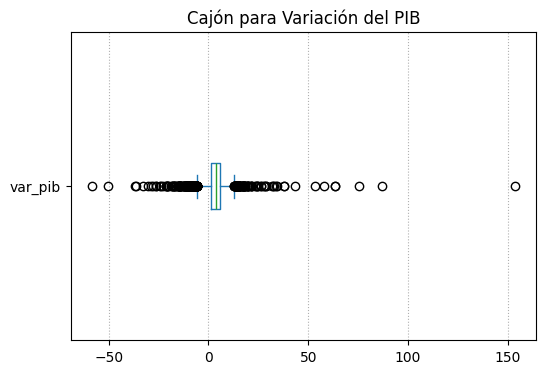

In [31]:
df_consolidado.plot(
    kind = "box",
    y = "var_pib",
    vert = False,
    figsize = [6,4],
    title = "Cajón para Variación del PIB"
)
plt.grid(axis = "x", linestyle = ":")
plt.show()

Para una mejor visualización de la distribución, repite el gráfico excluyendo los valores atípicos.

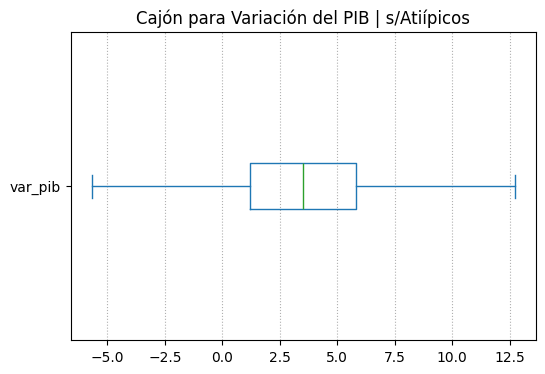

In [32]:
df_consolidado.plot(
    kind = "box",
    y = "var_pib",
    vert = False,
    figsize = [6,4],
    showfliers = False,
    title = "Cajón para Variación del PIB | s/Atiípicos"
)
plt.grid(axis = "x", linestyle = ":")
plt.show()

Vale señalar que un valor se considera atípico si el mismo NO se encuentra dentro del intervalo 

$$ \left[ Q_1 - 1.5(Q3-Q1),\; Q_3 + 1.5(Q3-Q1)\right]$$

donde $Q1$ es el primer cuartil y $Q3$ el tercero.

Complementa ahora este resultado con un histograma tal que cumplas con lo siguiente: 

* Excluye del dataset los casos atípicos.
* Utiliza un número de columnas ($c$) pertinente para lo cual puedes utilizar la fórmula $c \approx \sqrt{n}$, donde $n$ es el número de observaciones no atípicas.

In [33]:
# Excluir valores atípicos
umbral_inf = df_consolidado["var_pib"].quantile(0.25) - 1.5*(df_consolidado["var_pib"].quantile(0.75) - df_consolidado["var_pib"].quantile(0.25))
umbral_sup = df_consolidado["var_pib"].quantile(0.75) + 1.5*(df_consolidado["var_pib"].quantile(0.75) - df_consolidado["var_pib"].quantile(0.25))
df_sin_atipicos = df_consolidado.query("var_pib >= @umbral_inf and var_pib <= @umbral_sup")
df_sin_atipicos.shape

(4416, 7)

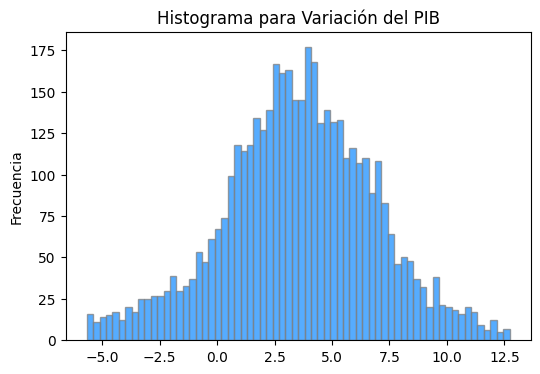

In [34]:
# Generar histograma
df_sin_atipicos.plot(
    kind = "hist",
    bins = int(np.sqrt(df_sin_atipicos.shape[0])),
    y = "var_pib",
    figsize = [6,4],
    legend = None,
    title = "Histograma para Variación del PIB",
    ylabel = "Frecuencia",
    edgecolor = "gray",
    color = "dodgerblue",
    alpha = 0.75
)
plt.show()

El histograma puede resumirse en un diagrama de densidad. Créalo.

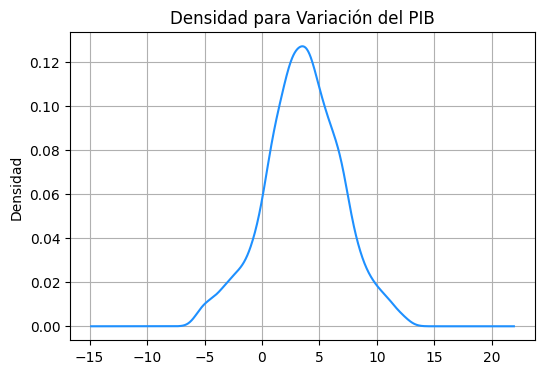

In [35]:
df_sin_atipicos.plot(
    kind = "density",
    y = "var_pib",
    figsize = [6,4],
    legend = None,
    title = "Densidad para Variación del PIB",
    color = "dodgerblue",
    grid = True
)
plt.ylabel("Densidad")
plt.show()

Genera finalmente un gráfico con la evolución a través de los años de la variación en el PIB promedio mundial.

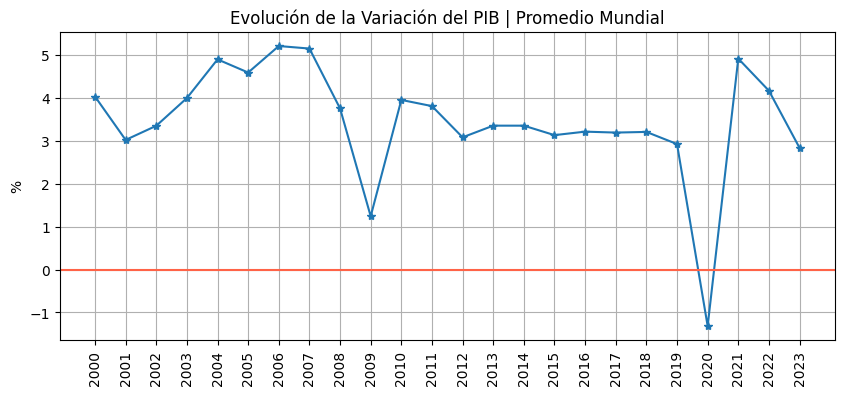

In [36]:
pib_anual = (
    df_sin_atipicos
    .groupby("year")
    .agg(var_pib = ("var_pib","mean"))
)

pib_anual.plot(
    figsize = [10,4],
    legend = None,
    marker = "*",
    xticks = range(2000,2024),
    rot = 90,
    grid = True,
    title = "Evolución de la Variación del PIB | Promedio Mundial",
    xlabel = "",
    ylabel = "%"
)
plt.axhline(y = 0, color = "tomato")
plt.show()

**CONCLUSIONES**

* El promedio de variación del PIB para un país en un año cualquiera en el nuevo milenio es de aprox. 3.5%, sin embargo se evidencia un alto nivel de volatilidad en este resultado producto a las distintas realidades de los países a nivel mundial, visto que cada estado enfrenta entornos socioeconómicos dispares.
* La crisis *subprime* del año 2009 conllevó un deterioro a nivel mundial en cuanto al desarrollo económico, sin embargo esto no es siquiera comparable con los efectos derivados de la pandemia del COVID en el año 2020, en el cual hubo una contracción de más de 4 puntos porcentuales respecto al promedio histórico.

### ¿Qué variables inciden principalmente en los cambios a nivel de este indicador?

Excluye del dataset los años 2009 y 2020 por ser especiales en cuanto a la situación mundial vivida en esos períodos.

In [37]:
per_excluir = [2009,2020]
df_sin_atipicos = df_sin_atipicos.query("year != @per_excluir")

Estudia el grado de correlación existente entre las distintas métricas que tienes disponibles. Recuerda que la correlación mide el grado de vinculación lineal existente entre un par de variables, tal que:

* Si su valor es cercano a -1, se dice que ambas variables mantiene una relación **inversamente proporcional**, esto es, cuando una se incrementa la otra disminuye.
* Si su valor es cercano a +1, se dice que ambas variables mantiene una relación **directamente proporcional**, esto es, cuando una se incrementa la otra igualmente aumenta.
* Si su valor es cercano a 0, se dice que ambas variables no tienen relación estadística alguna.

In [38]:
mat_corr = df_sin_atipicos[["var_pib","ahorro","var_pob","pct_urbana"]].corr()
print(mat_corr.round(4))

            var_pib  ahorro  var_pob  pct_urbana
var_pib      1.0000  0.1334   0.1775     -0.1955
ahorro       0.1334  1.0000   0.0538      0.2164
var_pob      0.1775  0.0538   1.0000     -0.2277
pct_urbana  -0.1955  0.2164  -0.2277      1.0000


Repite el cálculo pero ahora utiliza los promedios anuales de cada indicador.

In [39]:
prom_anuales = df_sin_atipicos.groupby("year")[["var_pib","ahorro","var_pob","pct_urbana"]].mean()
mat_corr = prom_anuales[["var_pib","ahorro","var_pob","pct_urbana"]].corr()
print(mat_corr.round(4))

            var_pib  ahorro  var_pob  pct_urbana
var_pib      1.0000  0.6123   0.1757     -0.2936
ahorro       0.6123  1.0000   0.1011      0.1214
var_pob      0.1757  0.1011   1.0000     -0.7646
pct_urbana  -0.2936  0.1214  -0.7646      1.0000


Visualiza la relación existente entre ahorro y var_pib mediante una gráfica de dispersión.

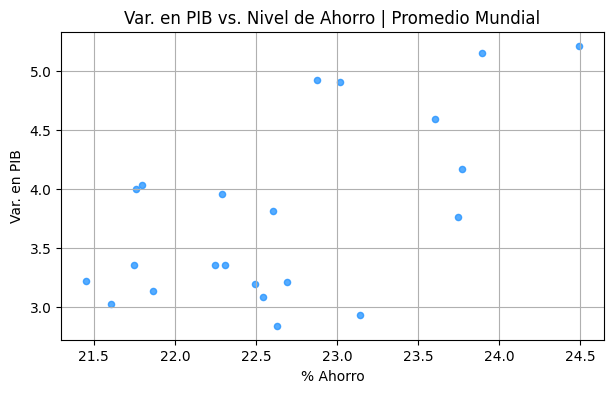

In [40]:
prom_anuales.plot(
    kind = "scatter",
    x = "ahorro",
    y = "var_pib",
    figsize = [7,4],
    color = "dodgerblue",
    alpha = 0.75,
    grid = True,
    title = "Var. en PIB vs. Nivel de Ahorro | Promedio Mundial",
    xlabel = "% Ahorro",
    ylabel = "Var. en PIB"
)
plt.show()

Visualiza ahora la relación existente entre pct_urbana y var_pib mediante una gráfica de dispersión.

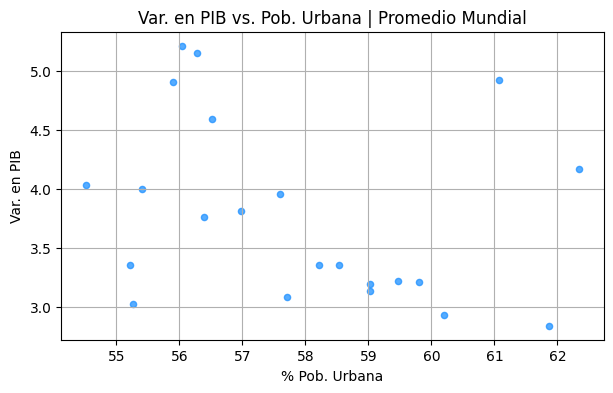

In [41]:
prom_anuales.plot(
    kind = "scatter",
    x = "pct_urbana",
    y = "var_pib",
    figsize = [7,4],
    color = "dodgerblue",
    alpha = 0.75,
    grid = True,
    title = "Var. en PIB vs. Pob. Urbana | Promedio Mundial",
    xlabel = "% Pob. Urbana",
    ylabel = "Var. en PIB"
)
plt.show()

**CONCLUSIONES**

* Si bien a nivel de cada país no se evidencia que el ningun indicador tiene una relación significativa con los cambios en el PIB (lo cual está aasociado al grado de volatilidad observado por las diversas condiciones y políticas socioeonómicas de cada estado), a nivel promedio se podría afirmar que un mayor ahorro de la población conlleva mejores niveles de crecimiento económico producto de una mayor capacidad financiera para la generación de capital y consumo.
* En esta línea, en promedio se evidencia una relación negativa entre el porcentaje de población urbana y variación en el PIB, lo cual da cuenta posiblemente de mayores potenciales de desarrollo en estados con alta incidencia agrícola y extractiva. Lo anterior no sugiere que estados con estas características sean más desarrollados que su contraparte, sino que los cambios observados a nivel de PIB son más grandes en términos porcentuales. 

### ¿Qué tan probable es que un país tenga una recesión en un año cualquiera?

Crea una nueva columna en el dataset de forma que se evidencien los casos en los que han existido recesiones.

In [42]:
df_sin_atipicos["es_recesion"] = df_sin_atipicos["var_pib"].apply(lambda x: True if x < 0 else False)
df_sin_atipicos.sample(5)

,country_code,country_name,year,var_pib,ahorro,var_pob,pct_urbana,es_recesion
3637,RWA,Rwanda,2013,4.719849,NaN,2.379292,16.947,False
4271,TTO,Trinidad y Tobago,2023,2.103245,NaN,0.253948,53.439,False
727,BWA,Botswana,2007,5.792556,44.516104,1.964957,57.928,False
3388,PLW,Palau,2004,3.939054,NaN,0.135723,70.383,False
2674,MDA,Republica de Moldova,2010,7.100000,17.005611,-0.099833,42.620,False


Calcula en cuántos casos del dataset han existido recesiones y guarda este resultado en una variable llamada `casos_exitosos`.

In [43]:
casos_exitosos = df_sin_atipicos["es_recesion"].sum()

Guarda la totalidad de casos posibles en la variable `casos_totales`.

In [44]:
casos_totales = df_sin_atipicos["es_recesion"].count()

Calcula la probabilidad de que en un año cualquiera un país entre en recesión. Recuerda que una probabilidad se mide como la razón entre los casos de éxito (eventos en los que sucede algo que estamos queriendo medir) y los casos totales observados. Además, una probabilidad debe cumplir 3 condiciones:

1. Es positiva, es decir, todo evento *puede* suceder.
2. Es estrictamente menor o igual a 1, es decir, existen otros eventos *posibles*.
3. La suma de todas las probabilidades de eventos posibles en un experimento es igual a 1, es decir, alguno *debe* suceder. 

In [45]:
prob_recesion = casos_exitosos / casos_totales
print(f"La probabilidad que un país entre en recesión en un año cualquiera es de: {prob_recesion:.1%}")

La probabilidad que un país entre en recesión en un año cualquiera es de: 10.1%


Vale que notes que esta probabilidad obtenida podría calcularse de forma directa con el siguiente código:

```py
prob_recesion = df_sin_atipicos["es_recesion"].mean()
```

Piensa el porqué esto funciona.

Encuentra el top 10 de países con una mayor probabilidad de recesión.

In [46]:
# Obtener probabilidad de recesión por pais
rec_por_pais = (
    df_sin_atipicos
    .groupby("country_name")
    .agg(prob_recesion = ("es_recesion","mean"))
    .sort_values(by = "prob_recesion", ascending = False)
)

In [47]:
# Extraer paises con mayor probabilidad
print(round(rec_por_pais.head(10) * 100,1))

                                   prob_recesion
country_name                                    
Samoa Americana                             57.1
Puerto Rico                                 54.5
Libia                                       42.9
Bermudas                                    40.9
Palau                                       38.1
Argentina                                   38.1
Barbados                                    38.1
Curacao                                     36.4
Micronesia (Estados Federados de)           36.4
Aruba                                       33.3


**CONCLUSIONES**

* En promedio, un año malo en términos económicos para un país puede presentarse una vez por cada década. De manera consecuente se pueden esperar ciclos de alrededor de 9 años de crecimiento sostenido en las economías nacionales, ante lo cual las políticas de desarrollo e inversión pública y privada deberían alinearse a esta realidad observada para así garantizar que las variaciones positivas en el PIB sean las máximas posibles en estos años.
* Resalta que entre los 10 países con mayor probabilidad de recesión, 5 sean de la región del Caribe. Lo anterior, da cuenta de la necesidad para el Banco Mundial de fortalecer su  asistencia en esta zona geográfica. De igual manera otros 3 estados rankeados pertenecen a Oceanía que igualmente debería ser considerado en la planificación de actividades futuras de la entidad. 

### ¿Existen diferencias en el crecimiento de países de "bajo desarrollo" frente a países de "alto desarrollo"?

Escoge 5 países que consideres de bajo desarrollo (i.e Ecuador, Bolivia, Guatemala, etc.), y 5 que consideres de alto desarrollo (i.e Estados Unidos, Alemania, Japón, etc.). Filtra el dataset de forma que solamente conserves estos países y adiciona una nueva columna que distinga a los dos grupos.  

In [48]:
# Filtrar dataset con paises de bajo y alto desarrollo
paises_bd = ["Ecuador", "Bolivia", "Guatemala", "Madagascar", "Nepal"]
paises_ad = ["Estados Unidos", "Alemania", "Japon", "Francia", "Canada"]
paises_sel = paises_ad.copy()
paises_sel.extend(paises_bd)
df_filtrado = df_sin_atipicos.query("country_name in @paises_sel")
df_filtrado["country_name"].unique()

array(['Bolivia', 'Canada', 'Alemania', 'Ecuador', 'Francia', 'Guatemala',
       'Japon', 'Madagascar', 'Nepal', 'Estados Unidos'], dtype=object)

In [49]:
# Adicionar columna con grupos de paises
df_filtrado["nivel_desarrollo"] = df_filtrado["country_name"].apply(lambda x: "Alto" if x in paises_ad else "Bajo")
df_filtrado.sample(10)

,country_code,country_name,year,var_pib,ahorro,var_pob,pct_urbana,es_recesion,nivel_desarrollo
3197,NPL,Nepal,2005,3.479181,30.685717,1.075359,15.149,False,Bajo
3195,NPL,Nepal,2003,3.945038,25.126766,1.375027,14.538,False,Bajo
784,CAN,Canada,2016,1.038551,19.146455,1.131540,81.300,False,Alto
2167,JPN,Japon,2007,1.483969,30.343380,0.114909,88.146,False,Alto
1286,ECU,Ecuador,2014,4.226065,26.554405,1.483599,63.261,False,Bajo
773,CAN,Canada,2005,3.210454,24.451754,0.947086,80.122,False,Alto
2709,MDG,Madagascar,2021,5.739616,11.242505,2.416869,39.207,False,Bajo
616,BOL,Bolivia,2016,4.263921,15.420051,1.547288,68.738,False,Bajo
1740,GTM,Guatemala,2012,2.974709,11.558543,1.777496,49.000,False,Bajo
1273,ECU,Ecuador,2001,4.206272,18.819055,1.719686,60.799,False,Bajo


Estudia comparativamente la distribución de var_pib en los países de alto y bajo desarrollo.

In [50]:
# Extraer muestra de valores de paises de alto desarrollo
vpib_alto = df_filtrado.query("nivel_desarrollo == 'Alto'")["var_pib"]
vpib_bajo = df_filtrado.query("nivel_desarrollo == 'Bajo'")["var_pib"]

In [51]:
# Calcular la media para ambos grupos
res_estadistico = pd.concat([vpib_alto.describe(),vpib_bajo.describe()], axis = 1)
res_estadistico.columns = ["Alto","Bajo"]
print(res_estadistico)

             Alto        Bajo
count  110.000000  109.000000
mean     1.992414    4.215437
std      1.339023    1.968839
min     -1.224289   -0.687954
25%      1.045412    3.132298
50%      1.929276    4.126723
75%      2.779567    5.398508
max      6.435210    9.818418


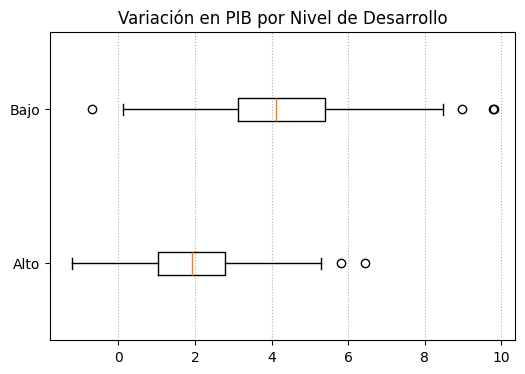

In [52]:
# Visualizar distribuciones con cajones
plt.figure(figsize = [6,4])
plt.boxplot([vpib_alto,vpib_bajo], vert = False)
plt.yticks(ticks = [1,2], labels = ["Alto","Bajo"])
plt.grid(axis = "x", linestyle = ":")
plt.title("Variación en PIB por Nivel de Desarrollo")
plt.show()

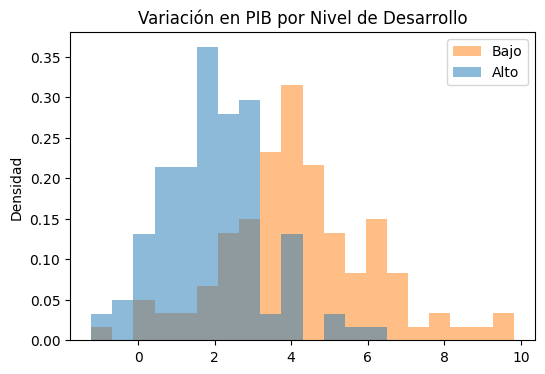

In [53]:
# Visualizar distribuciones con histogramas
plt.figure(figsize = [6,4])
plt.hist(
    [vpib_alto,vpib_bajo], 
    bins = 20, 
    density = True, 
    histtype = "stepfilled", 
    alpha = 0.5
)
plt.title("Variación en PIB por Nivel de Desarrollo")
plt.ylabel("Densidad")
plt.legend(["Bajo","Alto"])
plt.show()

Los resultados aquí alcanzados parecerían indicar que en promedio la variación del PIB en países de bajo desarrollo es mayor a aquella de los países de alto desarrollo. 

¿Cómo podemos estar completamente seguros de esta afirmación? La respuesta radica en la **Inferencia estadística**, cuyas técnicas nos permiten verificar hipótesis de forma objetiva y robusta.

Define por tanto tu hipótesis especificando su componente nulo y alternativo.

**DEFINICIÓN DE LA HIPÓTESIS NULA Y ALTERNATIVA**

* Hipótesis nula: La variación del PIB promedio en países de bajo desarrollo es IGUAL a la variación promedio en países de alto desarrollo.
* Hipótesis alternativa: La variación del PIB promedio en países de bajo desarrollo es MAYOR a la variación promedio en países de alto desarrollo.

Dado que nuestra hipótesis involucra a la **media** como estadístico, debemos utilizar técnicas de inferencia justamente enfocadas en este estadístico. Aquí algunas opciones populares:

* *Prueba Z*: Asume que las distribuciones del estadístico (media) sigue una distribución Normal y que las varianzas poblacionales de los datos son conocidas. 
* *Prueba T*: Asume que las distribuciones del estadístico sigue una distribución aproximadamente Normal y que las varianzas poblacionales de los datos son desconocidas.
* *Prueba U* de Mann-Whitney: No asume nada asociado a las distribuciones del estadístico.

En vista que no estamos seguros si en efecto las medias objeto de análisis siguen una distribución normal, aunque por los resultados alcanzados hasta ahora intuimos que aproximadamente sí lo hacen, aplica una *prueba T* para validar la hipótesis planteada mediante la función `ttest_ind`. 

In [54]:
prueba_t = st.ttest_ind(
    vpib_bajo, 
    vpib_alto, 
    equal_var = False, 
    alternative = "greater"
)
prueba_t

TtestResult(statistic=9.76151868530893, pvalue=8.36690091847756e-19, df=190.11727665902097)

Toda prueba de hipótesis entrega como resultado un *valor p* que mide la probabilidad de que si repetimos este experimento (extraer muestras de países de alto y bajo desarollo de manera aleatoria y contrastar sus medias), obtengamos como resultado variaciones del PIB iguales.

Visto esto no convendría descartar nuestra Hipótesis Nula si este *valor p* es significativo, digamos mayor a 5%. Pero sí la descartaríamos a favor de la Hipótesis Alternativa en caso contrario.

Ejecuta por tanto esta validación y por consiguiente verificando la afirmación especificada líneas arriba. 

In [55]:
valor_p = prueba_t.pvalue

if valor_p <= 0.05:
    resultado = "MAYOR"
else:
    resultado = "IGUAL"

print(f"Los países de bajo desarrollo tendrían {resultado} variación media del PIB con respecto a los paises de alto desarrollo.\nValor p: {valor_p:.4%}")

Los países de bajo desarrollo tendrían MAYOR variación media del PIB con respecto a los paises de alto desarrollo.
Valor p: 0.0000%


Ratifica este resultado con una prueba U Mann-Whitney (función `mannwhitneyu`).

In [56]:
# Ejecutar la prueba
prueba_mw = st.mannwhitneyu(
    vpib_bajo, 
    vpib_alto,
    alternative = "greater"
)

In [57]:
# Decidir en base a valor p
valor_p = prueba_mw.pvalue

if valor_p <= 0.05:
    resultado = "MAYOR"
else:
    resultado = "IGUAL"

print(f"Los países de bajo desarrollo tendrían {resultado} variación media del PIB con respecto a los paises de alto desarrollo.\nValor p: {valor_p:.4%}")

Los países de bajo desarrollo tendrían MAYOR variación media del PIB con respecto a los paises de alto desarrollo.
Valor p: 0.0000%


**CONCLUSIONES**

* Los países de bajo desarrollo tienden a crecer porcentaulmente más que los países más desarrollados. Esto en principio podría resultar contraintuitivo pero se explica por el hecho que incrementar 1 punto porcentual de una base menor es "más sencillo" que hacerlo de una base mayor. Aquí un ejemplo puramente ilustrativo:

    *Sea $100M el PIB de un país de bajo desarrollo en un año cualquiera, y $1,000M el de un pais de alto desarrollo. Incrementar 1% para el primer caso implica una variación absoluta de apenas $1 millón, mientras que para el segundo sería $10 millones. ¡Mucho más!*